In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#1565C0""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_min""","""#80CBC4""","""AbExp min""",-1


In [ ]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251128.parquet")
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251128_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
# variant_class = "non_coding"
# consequences_for_group = var_cons.filter(
#     pl.col('variant_class') == variant_class
# )['vep_consequence'].to_list()
# filter_expression = pl.any_horizontal(
#     (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
# )

min_range = -50
max_range = +50

anno = (
    anno
    .filter(
        #
        # (pl.col('consequence_5_prime_utr_variant')==1) &
        # Filter for non-coding variants
        # (pl.col('vep_cds') == False) &
        # (pl.col('mane_cds') == False) &
        # (pl.col('non_mane_cds') == False) &

        # Filter for coding variants
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True)) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &
        
        # Distance to TSS range
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

gpn_star_llr_calibrated_mean,dist_to_tss,abexp_abs_max,am_pathogenicity,score_pai3d,absplice2_max,esmscoremissense,gene_length,promoterai,mamphylop,id,abexp_min,loftee_hc,verphylop,tss,strand,absplice_dna_max,promoterai_abs,pangolin_score,gpn_score,delta_score,region,gene_name,cadd_raw
f32,i64,f32,f32,f32,f32,f32,i64,f32,f32,str,f32,i8,f32,i64,str,f32,f32,f32,f32,f32,str,str,f32
-6.409937,19,0.077023,null,null,0.000033,null,105436,-0.0202,1.625,"""chr20:50691523:T:A""",-0.077023,0,2.096,50691542,"""-1""",0.001,0.0202,0.0,-7.21,0.0,"""ENSG00000042062""","""RIPOR3""",1.995084
-0.186867,-42,0.019552,null,null,null,null,4495,-0.0164,0.241,"""chr19:11237407:G:T""",-0.019552,0,0.183,11237449,"""1""",null,0.0164,null,-1.46,null,"""ENSG00000130173""","""ANGPTL8""",0.054827
0.45861,15,0.018825,null,null,0.000033,null,12598,0.181,-1.406,"""chr6:26172073:C:T""",-0.018825,0,-1.372,26172058,"""1""",0.001,0.181,0.0,-0.57,0.0,"""ENSG00000274290""","""H2BC6""",-0.165275
-0.309106,-42,0.046495,null,null,null,null,50975,0.2906,-0.288,"""chr1:212414943:A:G""",-0.046495,0,-0.536,212414901,"""-1""",null,0.2906,null,-1.28,null,"""ENSG00000065600""","""PACC1""",0.946512
1.807989,-29,0.002667,null,null,null,null,12598,-0.6916,-0.441,"""chr6:26172029:A:C""",0.001765,0,-0.462,26172058,"""1""",null,0.6916,null,0.51,null,"""ENSG00000274290""","""H2BC6""",0.366808
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-7.850635,38,0.041647,null,null,0.000033,null,42514,0.0286,2.786,"""chr17:39687951:G:A""",-0.041647,0,6.116,39687913,"""1""",null,0.0286,0.0,-8.8,null,"""ENSG00000141736""","""ERBB2""",8.85058
-2.47183,21,0.01004,null,null,0.000033,null,42514,0.0386,-0.705,"""chr17:39687934:C:G""",-0.01004,0,-0.553,39687913,"""1""",null,0.0386,0.0,-3.02,null,"""ENSG00000141736""","""ERBB2""",1.126247
-1.973263,3,0.024002,null,null,0.000111,null,26395,0.0074,1.089,"""chr2:43838862:C:T""",-0.024002,0,0.135,43838865,"""-1""",0.002861,0.0074,0.0,-3.06,null,"""ENSG00000138075""","""ABCG5""",1.103936


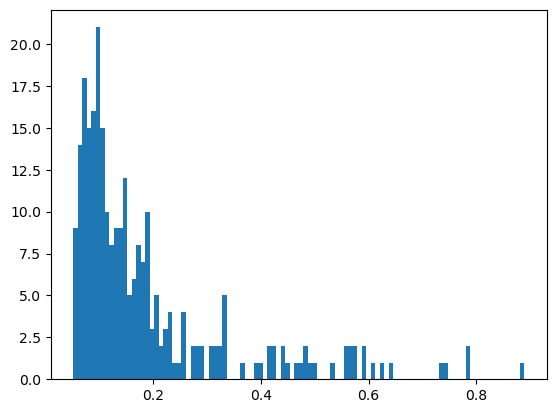

In [4]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [5]:
selected_annos = anno_config_df.filter(
    # Filter based on category regulatory_nondir
    pl.col('category').is_in(['genetic_diversity', 'conservation', 'regulatory_nondir']) # 'splicing'
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'missense']) # 'splicing'
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation']))
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,i8,f32,f32
"""chr20:50691523:T:A""","""ENSG00000042062""","""cadd_raw""",1.995084,"""genetic_diversity""",1,27.0,0.613636
"""chr19:11237407:G:T""","""ENSG00000130173""","""cadd_raw""",0.054827,"""genetic_diversity""",1,16.0,0.363636
"""chr6:26172073:C:T""","""ENSG00000274290""","""cadd_raw""",-0.165275,"""genetic_diversity""",1,7.0,0.070707
"""chr1:212414943:A:G""","""ENSG00000065600""","""cadd_raw""",0.946512,"""genetic_diversity""",1,57.0,0.670588
"""chr6:26172029:A:C""","""ENSG00000274290""","""cadd_raw""",0.366808,"""genetic_diversity""",1,66.0,0.666667
…,…,…,…,…,…,…,…
"""chr17:39687951:G:A""","""ENSG00000141736""","""abexp_abs_max""",0.041647,"""regulatory_nondir""",1,49.5,0.838983
"""chr17:39687934:C:G""","""ENSG00000141736""","""abexp_abs_max""",0.01004,"""regulatory_nondir""",1,24.0,0.40678
"""chr2:43838862:C:T""","""ENSG00000138075""","""abexp_abs_max""",0.024002,"""regulatory_nondir""",1,41.0,0.854167


In [6]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,i8,f32,f32,u64,u64
"""chr20:50691523:T:A""","""ENSG00000042062""","""cadd_raw""",1.995084,"""genetic_diversity""",1,27.0,0.613636,19,14503
"""chr19:11237407:G:T""","""ENSG00000130173""","""cadd_raw""",0.054827,"""genetic_diversity""",1,16.0,0.363636,65,23697
"""chr6:26172073:C:T""","""ENSG00000274290""","""cadd_raw""",-0.165275,"""genetic_diversity""",1,7.0,0.070707,4,34391
"""chr1:212414943:A:G""","""ENSG00000065600""","""cadd_raw""",0.946512,"""genetic_diversity""",1,57.0,0.670588,5,12418
"""chr6:26172029:A:C""","""ENSG00000274290""","""cadd_raw""",0.366808,"""genetic_diversity""",1,66.0,0.666667,210,12645
…,…,…,…,…,…,…,…,…,…
"""chr17:39687951:G:A""","""ENSG00000141736""","""abexp_abs_max""",0.041647,"""regulatory_nondir""",1,49.5,0.838983,46,5757
"""chr17:39687934:C:G""","""ENSG00000141736""","""abexp_abs_max""",0.01004,"""regulatory_nondir""",1,24.0,0.40678,10,21536
"""chr2:43838862:C:T""","""ENSG00000138075""","""abexp_abs_max""",0.024002,"""regulatory_nondir""",1,41.0,0.854167,2,5110


In [7]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

# ct_df['max_ptile'].min()

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""gpn_star_llr_calibrated_mean""",36680,1.0
"""gpn_score""",36680,1.0
"""cadd_raw""",36680,1.0
"""verphylop""",36608,1.0
"""mamphylop""",36608,1.0
"""abexp_abs_max""",36065,1.0
"""abexp_min""",36065,1.0
"""promoterai_abs""",35129,1.0


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [10]:
n_steps = 100
min_rank_cutoff = 100
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.95

cutoffs_list = np.logspace(
    np.log10(min_rank_cutoff), 
    np.log10(max_rank_cutoff), 
    num=n_steps
).tolist()

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": cutoffs_list})

cutoffs_lazy.collect()

rank_cutoff
f64
100.0
106.145925
112.669574
119.594162
126.94433
…
28894.555698
30670.393457
32555.372875


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff')
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""abexp_abs_max""","""ENSG00000196739""","""COL27A1""","""arm_predicted_mass_right_int""",100.0,0,0,2,25,NaN
"""cadd_raw""","""ENSG00000169047""","""IRS1""","""basal_metabolic_rate_int""",100.0,0,0,1,45,NaN
"""abexp_min""","""ENSG00000140443""","""IGF1R""","""basal_metabolic_rate_int""",100.0,0,0,4,60,NaN
"""mamphylop""","""ENSG00000084674""","""APOB""","""cholesterol_int""",100.0,0,0,2,30,NaN
"""verphylop""","""ENSG00000162711""","""NLRP3""","""creactive_protein_int""",100.0,0,0,2,17,NaN
…,…,…,…,…,…,…,…,…,…
"""mamphylop""","""ENSG00000119403""","""PHF19""","""basal_metabolic_rate_int""",36680.0,1,16,0,0,NaN
"""gpn_score""","""ENSG00000101004""","""NINL""","""creatinine_int""",36680.0,1,57,0,0,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000166603""","""MC4R""","""leg_predicted_mass_left_int""",36680.0,0,20,0,0,NaN


## Plotting

In [12]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'rank_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('rank_cutoff')
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""abexp_min""",310.572647,217,0.0,0.276498,0.276498,0.818433,-0.265438,"""#80CBC4""","""AbExp min"""
"""abexp_abs_max""",310.572647,227,0.0,0.264317,0.264317,0.782379,-0.253744,"""#00897B""","""AbExp abs max"""
"""abexp_abs_max""",329.66021,231,0.0,0.25974,0.25974,0.768831,-0.249351,"""#00897B""","""AbExp abs max"""
"""abexp_min""",329.66021,231,0.0,0.25974,0.25974,0.768831,-0.249351,"""#80CBC4""","""AbExp min"""
"""abexp_abs_max""",349.920879,242,0.0,0.538567,0.308869,1.14395,-0.066816,"""#00897B""","""AbExp abs max"""
…,…,…,…,…,…,…,…,…,…
"""verphylop""",34556.201716,134,0.075,0.112113,0.010382,0.132461,0.091765,"""#942c80""","""Vertebrate PhyloP"""
"""abexp_abs_max""",34556.201716,91,0.108108,0.152959,0.016331,0.184968,0.120951,"""#00897B""","""AbExp abs max"""
"""gpn_star_llr_calibrated_mean""",34556.201716,145,0.086957,0.115344,0.009158,0.133294,0.097395,"""#942c80""","""GPN-Star"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10


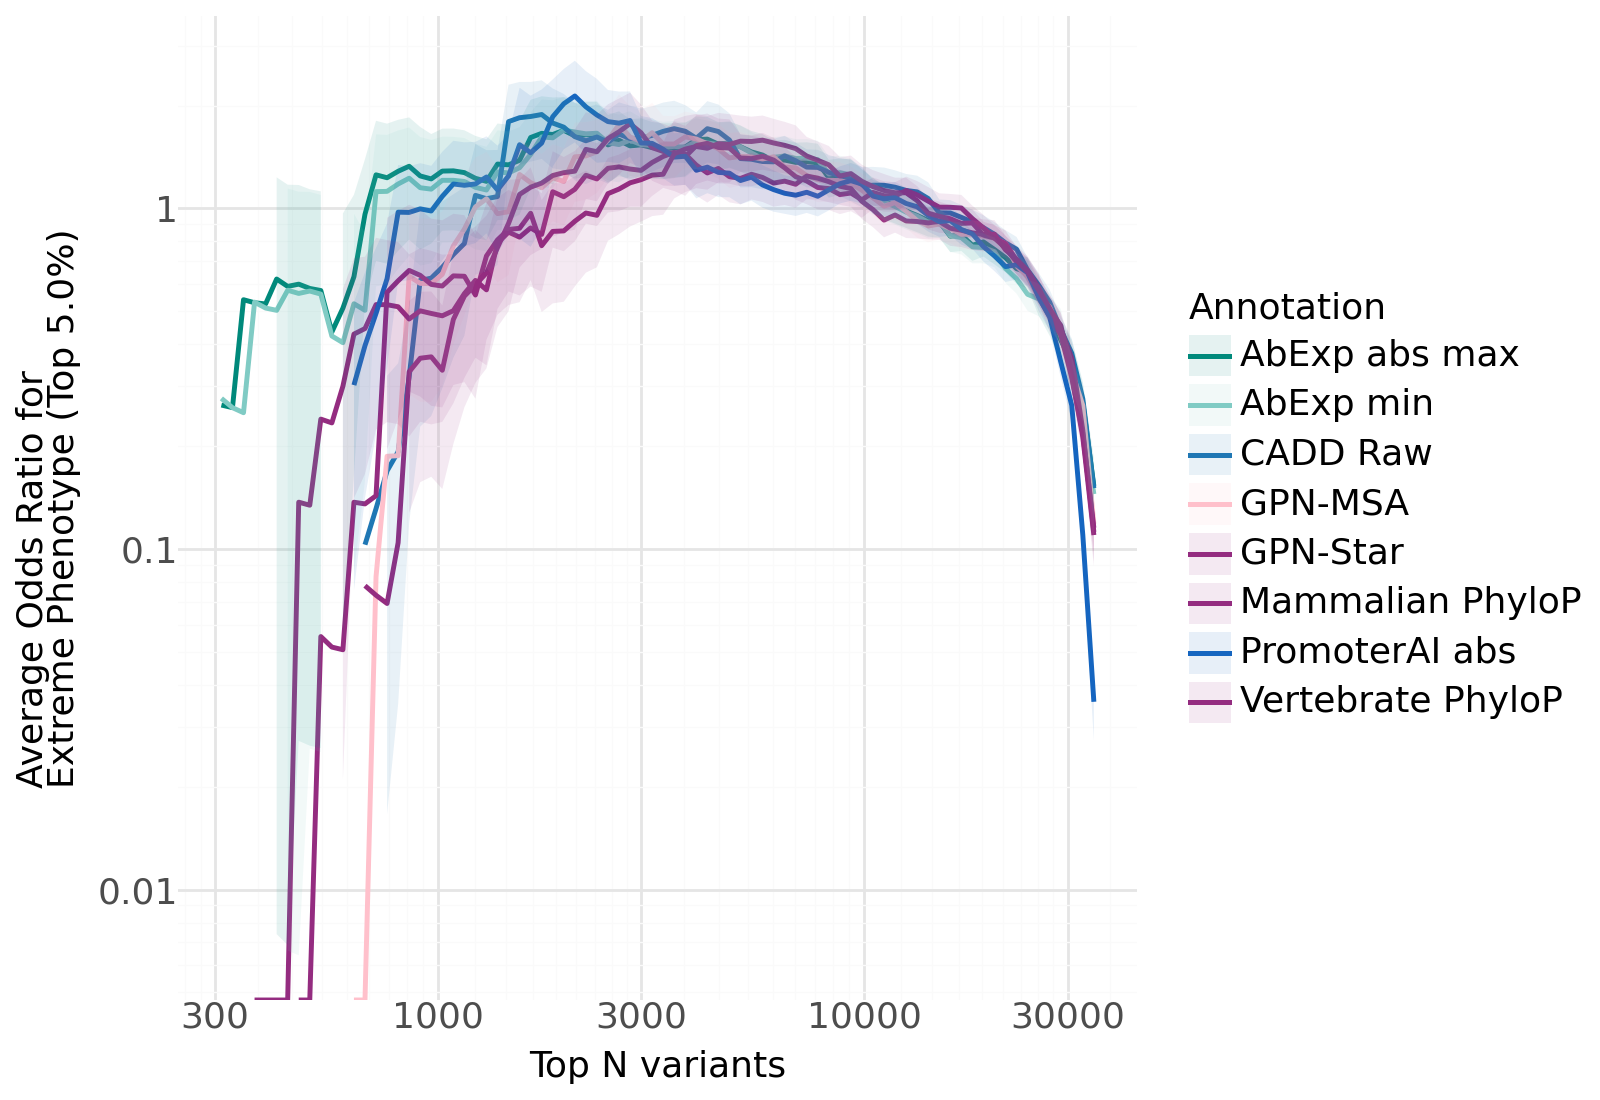

In [13]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [43179, 57191],
#     'mean_or': [8.963194, 3.196688],
#     'median_or': [3.724961, 1.955789],
# })

(
    ggplot(
        plt_df,
        # plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'gpn_score', 'pangolin_score', 'delta_score', 'am_pathogenicity', 'score_pai3d'])),
        # plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'delta_score'])),
        aes(x='rank_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)